In [2]:
import importlib
import numpy as np
import sys
sys.path.insert(0, '..')

import mcmc_polymer.lattice_rosenbluth as _lr_mod
import mcmc_polymer.pivot_alg as _pv_mod
importlib.reload(_lr_mod)
importlib.reload(_pv_mod)
from mcmc_polymer.lattice_rosenbluth import MultiChainRosenbluthMCMC
from mcmc_polymer.pivot_alg import PivotAlgorithm

import potentials.morse_discrete as _morse_mod
importlib.reload(_morse_mod)
from potentials.morse_discrete import DiscreteMorsePotential
from potentials.harmonic_wall_discrete import DiscreteHarmonicWallPotential

In [13]:
#In this example we create the coarse grained model of the cytoplasmic domain of a TCR-CD3 complex. The model is based on the work of Xu et al. (2020) and includes the TCR-CD3 complex as well as the membrane.
#The model is coarse grained to a resolution of 1 amino acids per bead.
#It is created on a grid with the grid length of 1 = 2.6 A which is the average radius of one amino acid. 
# The grid is a simple cubic lattice and the polymer chains are represented as self-avoiding walks on this lattice. 


#Lenght for the different chains
N_zeta= 164-52
N_epilon= 208-153
N_delta= 171-127
N_gamma= 182-137
N_gesamt = 2*N_zeta+2*N_epilon+N_gamma+N_delta
List_lengths = [N_zeta, N_zeta, N_epilon, N_epilon, N_delta, N_gamma]

In [ ]:
Zeta_a= [(103.46000, 121.81600, 158.16900),
(102.79800, 120.80800, 158.98800),
(103.38400, 120.76900, 160.39300),
(102.64200, 120.67800, 161.37800),
(102.13900, 118.34500, 159.05000),
(100.67400, 118.35800, 158.65000),
(99.84000,  118.98300, 159.67000), 
(98.59700,  119.39800, 159.47100),
(98.00800,  119.27400, 158.29300),
(97.92900,  119.95100, 160.47900)]
Zeta_b=[
(115.46700, 124.45800, 161.71100), 
(115.40600, 124.97000, 163.07700),
(114.10100, 124.59800, 163.77700),
(114.10900, 124.24400, 164.9630),
(115.59900, 126.47900, 163.10200),
(116.29500, 126.88500, 164.35500),
(117.64700, 126.24500, 164.42800),
(118.18000, 126.38700, 165.77100),
(118.79800, 127.47400, 166.19200),
(118.90500, 128.53300, 165.41700),
(119.29800, 127.50300, 167.42300)]
Delta_a =[
(125.89900, 115.81200, 165.12600),
(126.01600, 115.88700, 166.57200),
(125.18800, 116.99600, 167.19000),
(124.67700, 116.84900, 168.30300)]
Epsilon_a = [
(128.62300, 142.98100, 164.31300),
(127.66700, 142.13300, 165.01700),
(128.21000, 141.67600, 166.36300),
(127.47600, 141.65300, 167.35700),
(127.30100, 140.92700, 164.15800),
(126.40100, 140.08300, 164.85000)]
Epsilon_b=[
(126.02200, 108.61600, 161.89500),
(126.56000, 109.56300, 162.86200),
(125.56800, 109.95800, 163.94700),
(125.98700, 110.50300, 164.97400),
(127.04600, 110.82700, 162.14900),
(128.12500, 110.53800, 161.27900)]
Gamma_a= [
(127.73600, 135.18600, 164.41900),
(128.66200, 136.05000, 165.13600),
(128.47000, 135.89400, 166.63800),
(127.34500, 135.97500, 167.14200),
(128.46400, 137.50700, 164.72500)]

In [ ]:
AA_PER_LATTICE = 2.6   # Å — one lattice step = one amino acid radius

def get_avr_pos(data):
    arr = np.array(data)
    return arr.mean(axis=0)   # shape (3,)

Zeta_a_avr   = get_avr_pos(Zeta_a)
Zeta_b_avr   = get_avr_pos(Zeta_b)
Delta_a_avr  = get_avr_pos(Delta_a)
Epsilon_a_avr = get_avr_pos(Epsilon_a)
Epsilon_b_avr = get_avr_pos(Epsilon_b)
Gamma_a_avr  = get_avr_pos(Gamma_a)

# Shift all positions relative to Zeta_a, convert to lattice units, snap to grid
def to_lattice(pos, reference):
    return np.round((pos - reference) / AA_PER_LATTICE).astype(int)

Zeta_a_start   = to_lattice(Zeta_a_avr,   Zeta_a_avr)
Zeta_b_start   = to_lattice(Zeta_b_avr,   Zeta_a_avr)
Delta_a_start  = to_lattice(Delta_a_avr,  Zeta_a_avr)
Epsilon_a_start = to_lattice(Epsilon_a_avr, Zeta_a_avr)
Epsilon_b_start = to_lattice(Epsilon_b_avr, Zeta_a_avr)
Gamma_a_start  = to_lattice(Gamma_a_avr,  Zeta_a_avr)

STARTS = [Zeta_a_start, Zeta_b_start, Epsilon_a_start,
          Epsilon_b_start, Delta_a_start, Gamma_a_start]

print(f"Lattice unit = {AA_PER_LATTICE} Å  (one amino acid radius)")
print()
print(f"{'Chain':<14}  {'Lattice start (x, y, z)':>28}")
print("-" * 46)
for name, pos in zip(["Zeta_a", "Zeta_b", "Epsilon_a", "Epsilon_b", "Delta_a", "Gamma_a"], STARTS):
    print(f"{name:<14}  {str(tuple(pos)):>28}")

Lattice unit = 2.6 Å  (one amino acid radius)

Chain                Lattice start (x, y, z)
----------------------------------------------
Zeta_a                             (0, 0, 0)
Zeta_b                             (6, 2, 2)
Epsilon_a                         (10, 8, 2)
Epsilon_b                        (10, -4, 1)
Delta_a                           (9, -1, 3)
Gamma_a                           (10, 6, 2)


In [17]:
N_SAMPLES = 100000

chain_lengths = [N_zeta, N_zeta, N_epilon, N_epilon, N_delta, N_gamma]

sampler = MultiChainRosenbluthMCMC(
    n_chains     = len(STARTS),
    n_monomers   = chain_lengths,
    walls        = [],
)

print(f"Growing {N_SAMPLES} joint configurations ...")
print(f"  Chains : {len(STARTS)}")
for name, length, start in zip(
    ["Zeta_a", "Zeta_b", "Epsilon_a", "Epsilon_b", "Delta_a", "Gamma_a"],
    chain_lengths, STARTS
):
    print(f"    {name:<12}  {length:>4} monomers  start={tuple(start)}")
print()

configs, weights = sampler.sample(N_SAMPLES, starts=STARTS)

weights      = np.array(weights)
n_dead       = int(np.sum(weights == 0))
n_alive      = N_SAMPLES - n_dead
w_live       = weights[weights > 0]

print(f"Results")
print(f"  Dead-end configurations : {n_dead} / {N_SAMPLES}  ({100*n_dead/N_SAMPLES:.1f}%)")
print(f"  Live configurations     : {n_alive}")
if n_alive > 0:
    print(f"  Weight min / max        : {w_live.min():.3e} / {w_live.max():.3e}")
    print(f"  Effective sample size   : {w_live.sum()**2 / (w_live**2).sum():.1f}")

Growing 100000 joint configurations ...
  Chains : 6
    Zeta_a         112 monomers  start=(0, 0, 0)
    Zeta_b         112 monomers  start=(6, 2, 2)
    Epsilon_a       55 monomers  start=(10, 8, 2)
    Epsilon_b       55 monomers  start=(10, -4, 1)
    Delta_a         44 monomers  start=(9, -1, 3)
    Gamma_a         45 monomers  start=(10, 6, 2)

Results
  Dead-end configurations : 6294 / 100000  (6.3%)
  Live configurations     : 93706
  Weight min / max        : 1.519e-34 / 1.117e-07
  Effective sample size   : 22.7


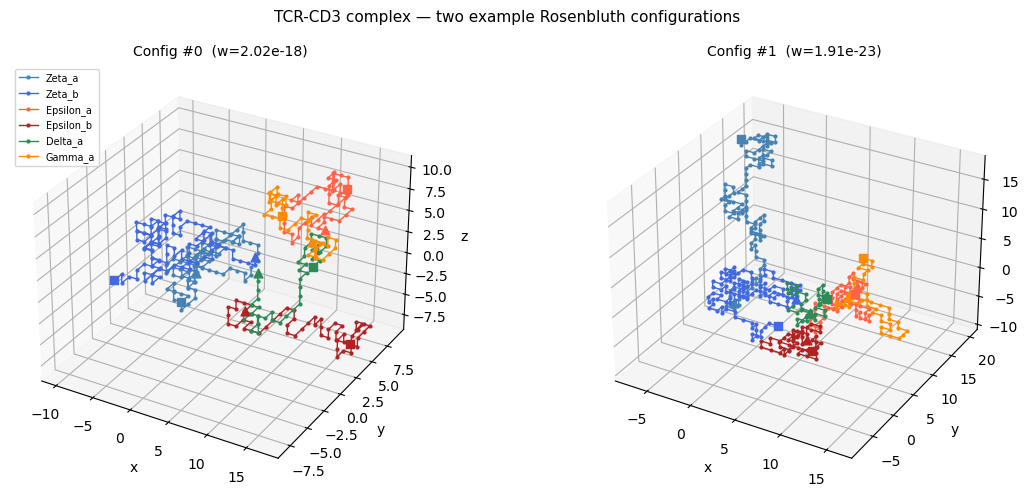

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

CHAIN_NAMES  = ["Zeta_a", "Zeta_b", "Epsilon_a", "Epsilon_b", "Delta_a", "Gamma_a"]
CHAIN_COLORS = ["steelblue", "royalblue", "tomato", "firebrick", "seagreen", "darkorange"]

# pick two live configurations
live_idx = np.where(weights > 0)[0]
example_idx = live_idx[:2]

fig = plt.figure(figsize=(12, 5))

for plot_col, cfg_idx in enumerate(example_idx):
    ax = fig.add_subplot(1, 2, plot_col + 1, projection='3d')
    chains = configs[cfg_idx]

    for chain, name, color in zip(chains, CHAIN_NAMES, CHAIN_COLORS):
        ax.plot(chain[:, 0], chain[:, 1], chain[:, 2],
                '-o', color=color, markersize=2, linewidth=1, label=name)
        ax.scatter(*chain[0],  color=color, s=40, marker='^', zorder=5)   # start
        ax.scatter(*chain[-1], color=color, s=40, marker='s', zorder=5)   # end

    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(f'Config #{cfg_idx}  (w={weights[cfg_idx]:.2e})', fontsize=10)
    if plot_col == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('TCR-CD3 complex — two example Rosenbluth configurations', fontsize=11)
plt.tight_layout()
plt.savefig('../data/tcr_cd3_example_configs.png', dpi=150, bbox_inches='tight')
plt.show()

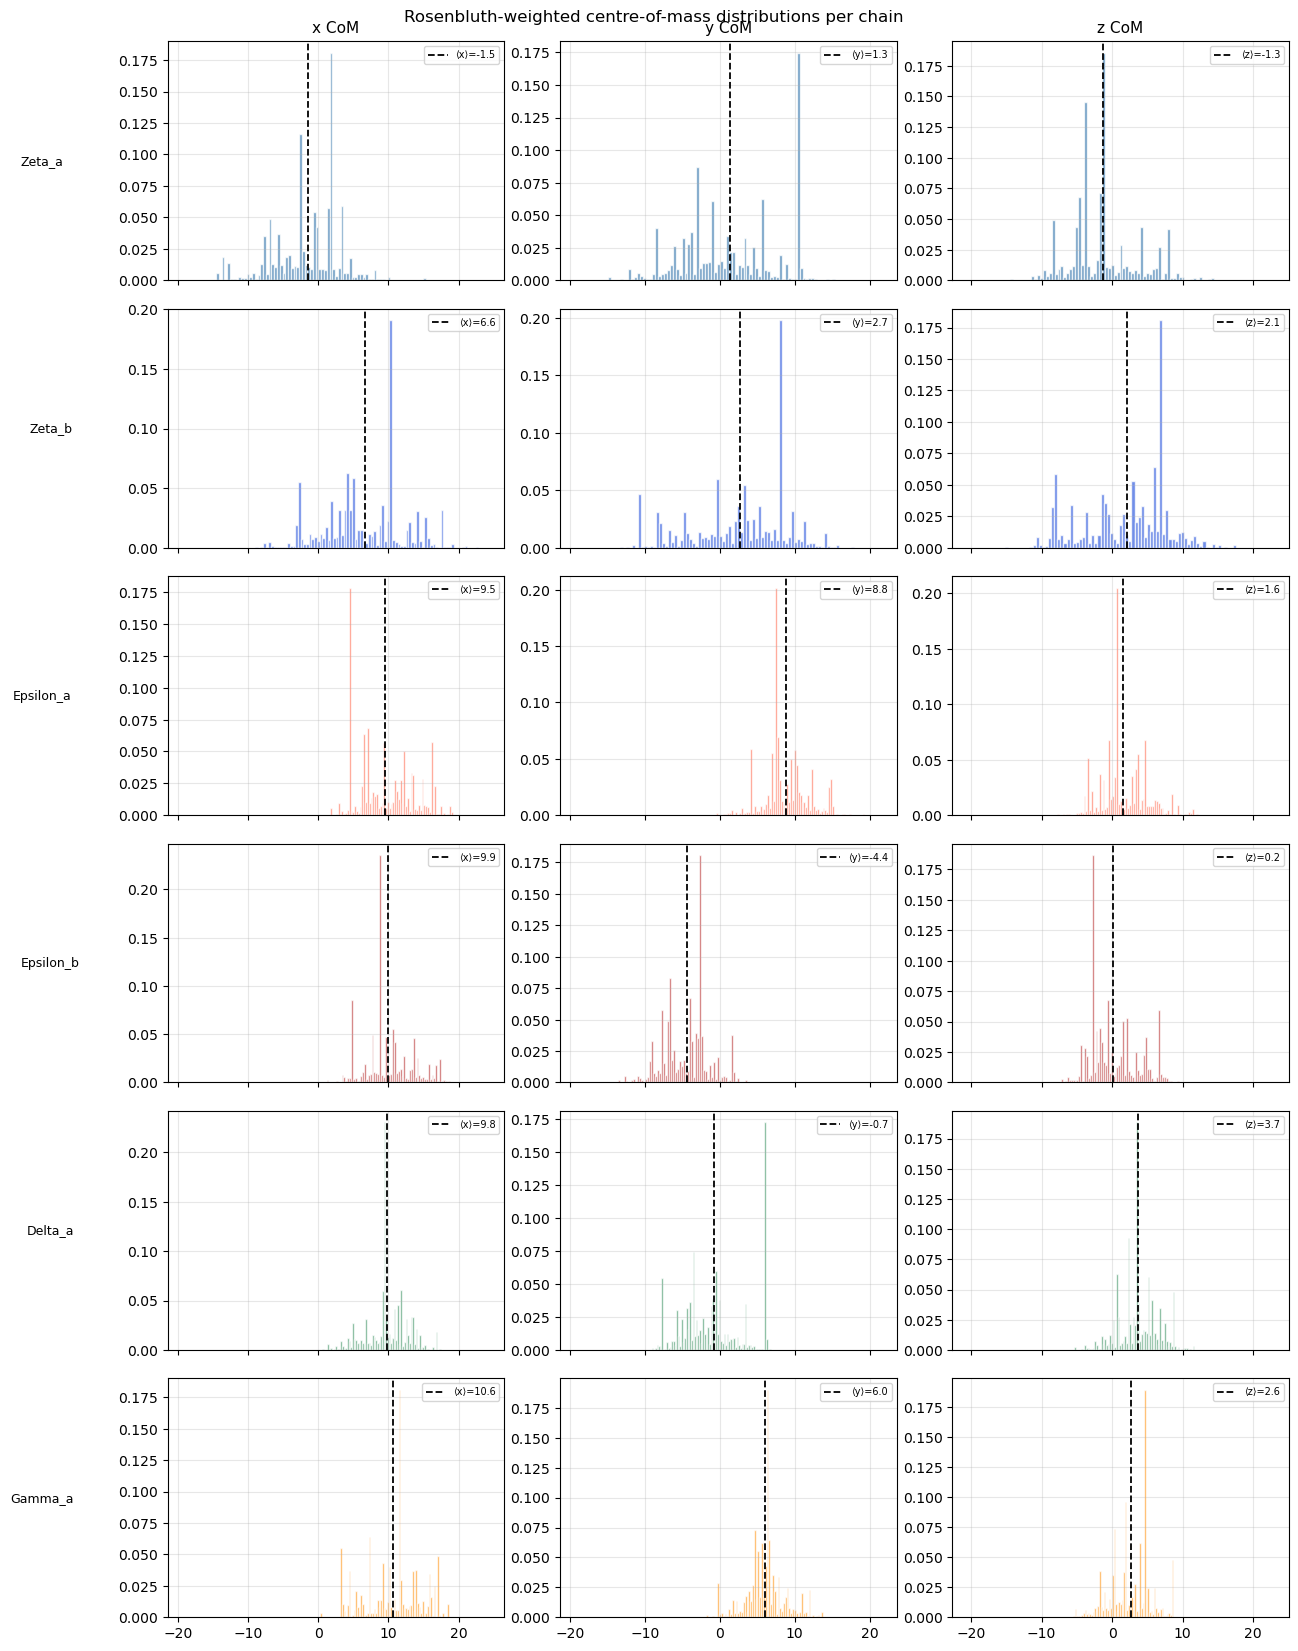

In [20]:
# Centre-of-mass distribution per chain (Rosenbluth-weighted)
live_mask = weights > 0
w_live    = weights[live_mask]
live_cfgs = [configs[i] for i in np.where(live_mask)[0]]

n_chains    = len(CHAIN_NAMES)
axis_labels = ['x', 'y', 'z']

fig, axes = plt.subplots(n_chains, 3, figsize=(13, 2.8 * n_chains), sharex='col')

for k, (name, color) in enumerate(zip(CHAIN_NAMES, CHAIN_COLORS)):
    # weighted CoM for each live configuration
    com = np.array([cfg[k].mean(axis=0) for cfg in live_cfgs])   # (n_live, 3)

    for col, axis_name in enumerate(axis_labels):
        ax   = axes[k, col]
        data = com[:, col]
        bins = np.linspace(data.min() - 0.5, data.max() + 0.5, 100)

        # weighted histogram
        w_mean = np.average(data, weights=w_live)
        ax.hist(data, bins=bins, weights=w_live / w_live.sum(),
                color=color, alpha=0.75, edgecolor='white')
        ax.axvline(w_mean, color='k', linestyle='--', linewidth=1.3,
                   label=f'⟨{axis_name}⟩={w_mean:.1f}')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        if k == 0:
            ax.set_title(f'{axis_name} CoM', fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=9, rotation=0, labelpad=55, va='center')

fig.suptitle('Rosenbluth-weighted centre-of-mass distributions per chain', fontsize=12)
plt.tight_layout()
plt.savefig('../data/tcr_cd3_com_distributions.png', dpi=150, bbox_inches='tight')
plt.show()